In [ ]:
# Step 1: Import pandas
import pandas as pd
import numpy as np

# Step 2: Load CSV from URL
url = 'csv/dufour_onsets_librosa_unfiltered.csv'
df = pd.read_csv(url)

# Step 3: Display the first few rows of the DataFrame
display(df)

# Onset times in seconds
onset_times = df['onset_times'].values

# Calculate inter-onset intervals (IOIs)
iois = np.diff(onset_times)

,onset_times
0,0.110295
1,0.400544
2,2.618050
3,4.858776
4,7.082086
...,...
91,67.401723
92,68.127347
93,68.673016
94,69.125805


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import mido

# --- IOI Analysis and Grid Finding Functions ---
# (analyze_iois and evaluate_grid_fit functions remain the same, so they are omitted here for brevity)
# (Just make sure they are in your notebook cell)

def analyze_iois(df, onset_column):
    """Calculates and visualizes IOIs from a DataFrame."""
    if onset_column not in df.columns:
        print(f"Error: Column '{onset_column}' not found. Available columns: {list(df.columns)}")
        return np.array([]), {}
    onset_times = df[onset_column].values
    if len(onset_times) < 2: return np.array([]), {}
    iois = np.diff(onset_times)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Inter-Onset Interval (IOI) Analysis', fontsize=16)
    ax1.plot(iois, marker='.', linestyle='-', color='teal')
    ax1.set_title('IOI Sequence'); ax1.set_xlabel('Event Number'); ax1.set_ylabel('Interval Duration (s)'); ax1.grid(True, linestyle='--', alpha=0.6)
    ax2.hist(iois, bins=30, color='skyblue', edgecolor='black')
    ax2.set_title('IOI Distribution (Histogram)'); ax2.set_xlabel('Interval Duration (s)'); ax2.set_ylabel('Frequency'); ax2.grid(True, linestyle='--', alpha=0.6)
    stats = {'mean': np.mean(iois), 'std': np.std(iois)}
    stats['cv'] = stats['std'] / stats['mean'] if stats['mean'] != 0 else 0
    ax2.axvline(stats['mean'], color='red', linestyle='--', label=f"Mean: {stats['mean']:.3f}s"); ax2.legend()
    plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()
    return iois, stats

# --- (MODIFIED) find_optimal_grid_period Function ---
def find_optimal_grid_period(iois, min_period=0.1, max_period=1.0, num_steps=1000, top_n_to_label=5):
    """
    Searches for optimal grid periods, now with cleaner plotting.

    Args:
        iois (np.ndarray): Array of Inter-Onset Intervals.
        min_period (float): The minimum period to test.
        max_period (float): The maximum period to test.
        num_steps (int): The number of steps in the search range.
        top_n_to_label (int): The number of best candidates to label on the plot.

    Returns:
        tuple: A tuple containing two numpy arrays:
            - candidate_periods (np.ndarray): Array of periods at local minima.
            - candidate_errors (np.ndarray): Array of error values at those minima.
    """
    base_values = np.linspace(min_period, max_period, num_steps)
    errors = np.array([np.sum((iois - v * np.round(iois / v))**2) for v in base_values])
    
    minima_indices, _ = find_peaks(-errors, distance=5)

    if minima_indices.size == 0:
        plt.figure(figsize=(12, 6))
        plt.plot(base_values, errors, label='Quantization Error')
        plt.title('Grid Period Finding - No Local Minima Found')
        plt.show()
        return np.array([]), np.array([])

    # --- Improved Plotting Logic ---
    candidate_periods = base_values[minima_indices]
    candidate_errors = errors[minima_indices]

    # Sort candidates by error to find the best ones
    sorted_indices = np.argsort(candidate_errors)
    best_n_indices = minima_indices[sorted_indices[:top_n_to_label]]
    
    plt.figure(figsize=(12, 7))
    # Plot the main error curve
    plt.plot(base_values, errors, label='Quantization Error', color='royalblue', zorder=1)
    
    # Plot ALL found minima as small red dots
    plt.plot(candidate_periods, candidate_errors, 'o', color='red', markersize=5, label='All Local Minima', zorder=2)

    # Highlight the single BEST minimum with a prominent star
    best_idx = minima_indices[sorted_indices[0]]
    plt.plot(base_values[best_idx], errors[best_idx], '*', color='gold', markersize=15, markeredgecolor='black', label='Best Candidate', zorder=4)

    # Add text labels for only the TOP N candidates
    for idx in best_n_indices:
        plt.text(base_values[idx] + 0.005, errors[idx], f'{base_values[idx]:.3f}s', color='black', zorder=3,
                 bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', boxstyle='round,pad=0.2'))

    plt.title('Grid Period Finding by Error Minimization')
    plt.xlabel('Candidate Grid Period (s)')
    plt.ylabel('Error (Sum of Squared Residuals)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()
    
    return candidate_periods, candidate_errors

# --- Make sure your other functions (analyze_iois, evaluate_grid_fit) are also in this cell ---

def evaluate_grid_fit(iois, base_period):
    """Evaluates and visualizes how well a given grid period fits the IOI data."""
    multipliers = np.round(iois / base_period)
    reconstructed_iois = base_period * multipliers
    residuals = iois - reconstructed_iois
    df_results = pd.DataFrame({'Original_IOI': iois, 'Multiplier': multipliers.astype(int), 'Reconstructed_IOI': reconstructed_iois, 'Residual': residuals})
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Evaluation of Grid Fit for Period = {base_period:.3f}s', fontsize=16)
    ax1.plot(df_results['Original_IOI'], 'o-', label='Original IOIs', color='teal', alpha=0.8)
    ax1.plot(df_results['Reconstructed_IOI'], 'x--', label='Reconstructed Grid', color='coral', markersize=8)
    ax1.set_title('Original vs. Reconstructed IOIs'); ax1.set_xlabel('Event Number'); ax1.set_ylabel('IOI Duration (s)'); ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.6)
    ax2.hist(df_results['Residual'], bins=20, color='lightcoral', edgecolor='black')
    ax2.axvline(0, color='black', linestyle='--', label='Perfect Grid Alignment')
    ax2.set_title('Distribution of Residuals (Timing Deviations)'); ax2.set_xlabel('Residual Duration (s)'); ax2.set_ylabel('Frequency'); ax2.legend(); ax2.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()
    return df_results

--- Step 1: Initial IOI Analysis ---


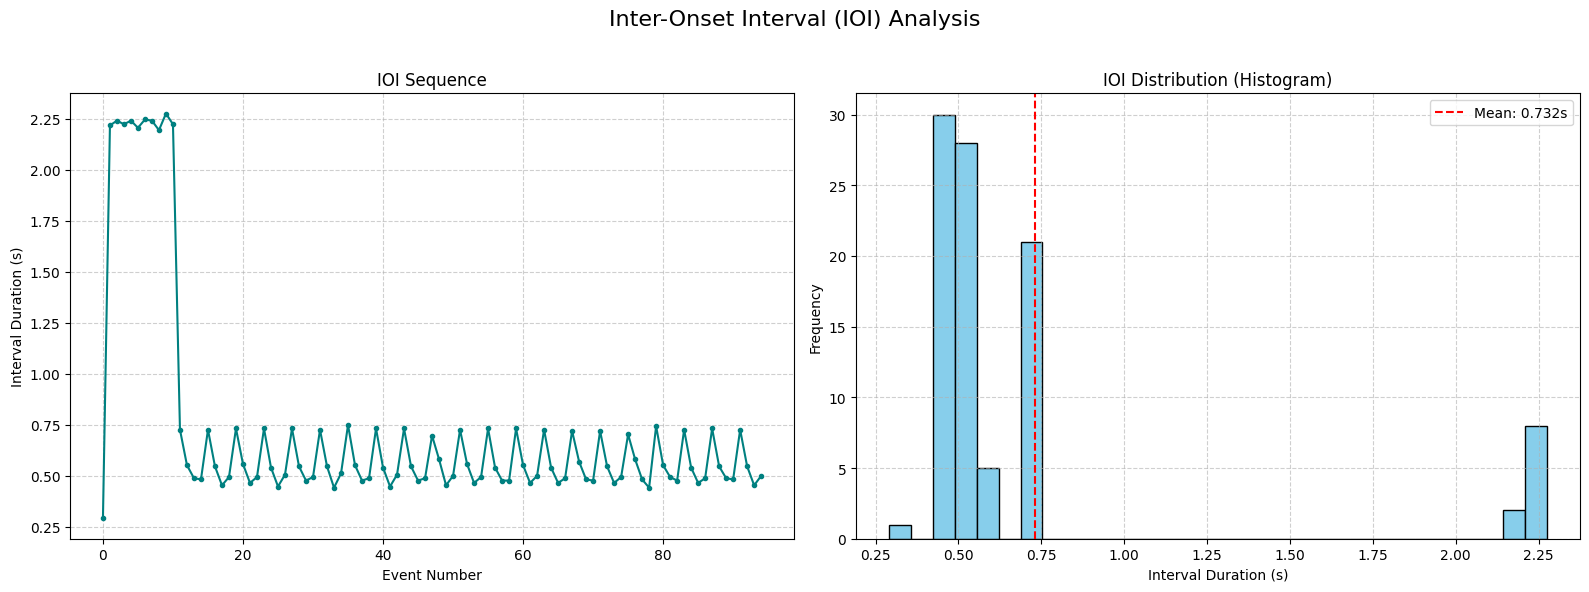


--- Step 2: Searching for Optimal Grid Period (Range: 0.2s - 0.5s) ---


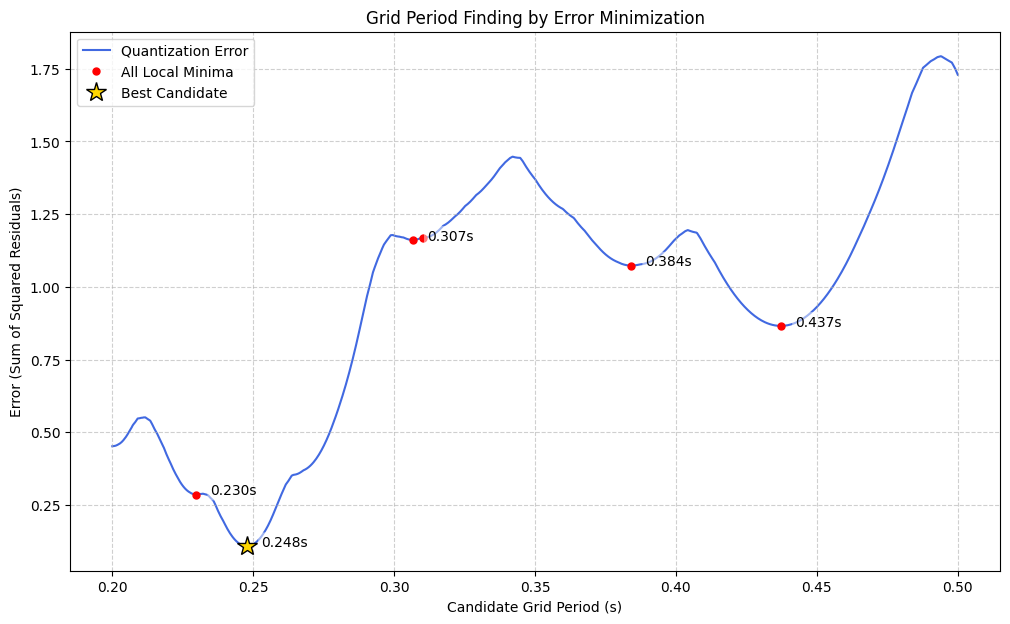


Top 5 potential grid period(s) (sorted by error):
  - Period: 0.2477 s,  Error (Loss): 0.1085  <-- Best
  - Period: 0.2297 s,  Error (Loss): 0.2861
  - Period: 0.4372 s,  Error (Loss): 0.8658
  - Period: 0.3841 s,  Error (Loss): 1.0730
  - Period: 0.3066 s,  Error (Loss): 1.1613
---------------------------------------------

--- Step 3: Evaluating the Chosen Candidate Grid ---
Automatically evaluating best-fit period: 0.2477 s


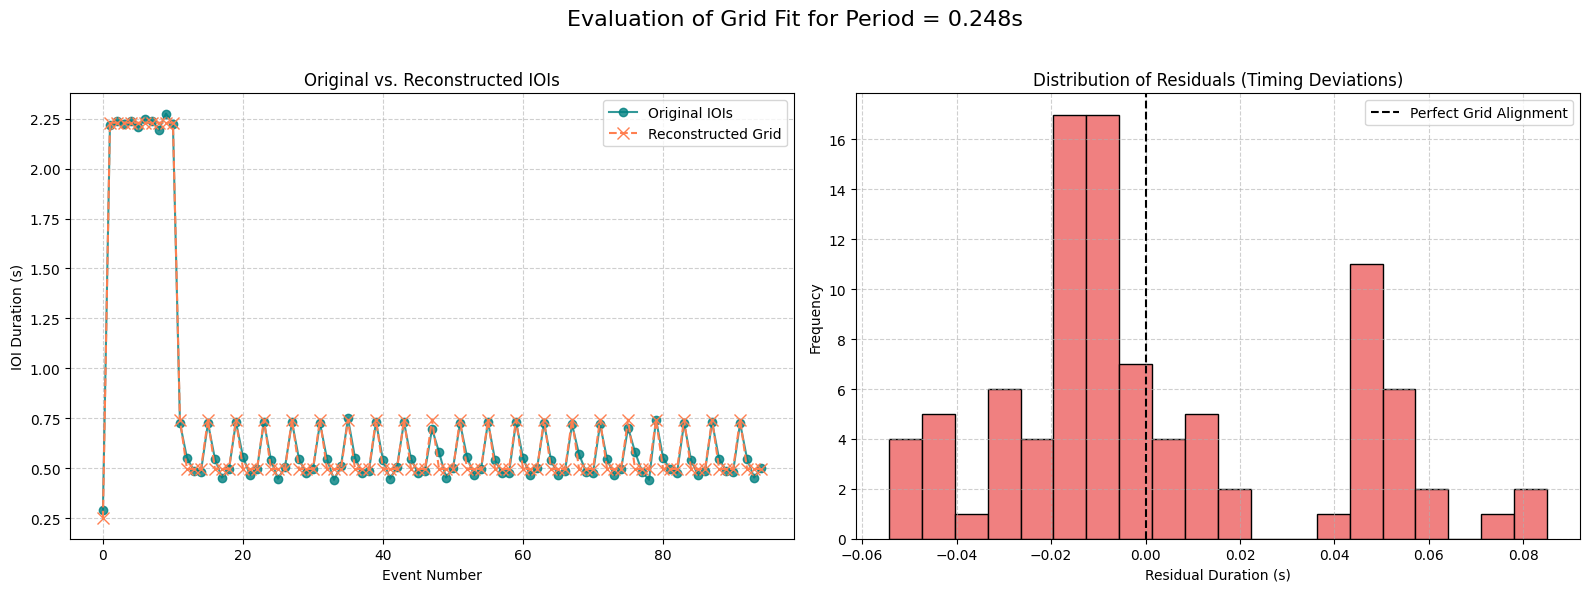


Analysis Results Table (first 5 rows):


,Original_IOI,Multiplier,Reconstructed_IOI,Residual
0,0.290249,1,0.247748,0.042502
1,2.217506,9,2.229730,-0.012224
2,2.240726,9,2.229730,0.010996
3,2.223311,9,2.229730,-0.006419
4,2.240726,9,2.229730,0.010996


In [41]:
# ===================================================================
#                          CONFIGURATION
# ===================================================================

# --- Data Configuration ---
ONSET_COLUMN_NAME = 'onset_times'

# --- Grid Search Configuration ---
MIN_GRID_PERIOD_S = 0.2
MAX_GRID_PERIOD_S = 0.5
TOP_N_CANDIDATES = 5 # How many of the best candidates to show in the list and plot

# --- Evaluation Configuration ---
# To manually select a period, set this to a number (e.g., 0.247).
# To use the automatic best-fit, set this to None.
MANUAL_GRID_PERIOD_S = None # <-- SET A VALUE HERE TO OVERRIDE

# --- Results Display Configuration ---
SHOW_FULL_RESULTS_DF = False

# ===================================================================
#                         ANALYSIS WORKFLOW
# ===================================================================

if 'df' in locals() and isinstance(df, pd.DataFrame):
    
    # --- Step 1: Perform Initial IOI Analysis ---
    print("--- Step 1: Initial IOI Analysis ---")
    iois, ioi_stats = analyze_iois(df, onset_column=ONSET_COLUMN_NAME)

    if iois.size > 0:
        # --- Step 2: Find Candidate Grid Periods ---
        print(f"\n--- Step 2: Searching for Optimal Grid Period (Range: {MIN_GRID_PERIOD_S}s - {MAX_GRID_PERIOD_S}s) ---")
        candidate_periods, candidate_errors = find_optimal_grid_period(
            iois, 
            min_period=MIN_GRID_PERIOD_S, 
            max_period=MAX_GRID_PERIOD_S,
            top_n_to_label=TOP_N_CANDIDATES
        )
        
        if candidate_periods.size > 0:
            # Create a sorted list of candidates
            sorted_candidates = sorted(zip(candidate_periods, candidate_errors), key=lambda item: item[1])
            
            print(f"\nTop {min(TOP_N_CANDIDATES, len(sorted_candidates))} potential grid period(s) (sorted by error):")
            for i, (period, error) in enumerate(sorted_candidates[:TOP_N_CANDIDATES]):
                marker = "  <-- Best" if i == 0 else ""
                print(f"  - Period: {period:.4f} s,  Error (Loss): {error:.4f}{marker}")
            print("-" * 45 + "\n")

            # --- Step 3: Evaluate the Chosen Candidate ---
            print("--- Step 3: Evaluating the Chosen Candidate Grid ---")
            
            # Decide whether to use manual or automatic period
            if MANUAL_GRID_PERIOD_S is not None:
                chosen_period = MANUAL_GRID_PERIOD_S
                print(f"Manually evaluating user-specified period: {chosen_period:.4f} s")
            else:
                # Automatically select the best candidate (the first in the sorted list)
                chosen_period = sorted_candidates[0][0]
                print(f"Automatically evaluating best-fit period: {chosen_period:.4f} s")
            
            results_df = evaluate_grid_fit(iois, chosen_period)
            
            # Display results table based on configuration
            if SHOW_FULL_RESULTS_DF:
                print("\nDisplaying full Analysis Results Table:")
                try: display(results_df)
                except NameError: print(results_df.to_string())
            else:
                print("\nAnalysis Results Table (first 5 rows):")
                try: display(results_df.head())
                except NameError: print(results_df.head())
        else:
            print("\nCould not find any distinct grid periods in the specified range.")
else:
    print("\nERROR: DataFrame 'df' not found. Please run the data loading cell before this.")

In [42]:
import mido

# --- Pre-computation Check ---
# Ensure the 'results_df' and 'chosen_period' variables from the analysis exist.
if 'results_df' not in locals() or 'chosen_period' not in locals():
    print("Error: Please run the analysis cells first to generate 'results_df' and 'chosen_period'.")
else:
    # ===================================================================
    #                  MIDI GENERATION PARAMETERS (ADJUST THESE)
    # ===================================================================

    # 1. DURATION MODE: Choose how note duration is calculated.
    #    Options: 'ioi_ratio' or 'fixed_ms'
    duration_mode = 'ioi_ratio'

    # 2. PARAMETERS FOR 'ioi_ratio' MODE
    #    (Used only if duration_mode is 'ioi_ratio')
    #    - 0.5 = Staccato (notes are half the length of the interval)
    #    - 1.0 = Legato (notes connect perfectly)
    note_duration_ratio = 0.8

    # 3. PARAMETERS FOR 'fixed_ms' MODE
    #    (Used only if duration_mode is 'fixed_ms')
    #    This sets a constant duration for every note.
    note_duration_ms = 100

    # 4. GENERAL MIDI PARAMETERS
    #    - Pitch (0-127): 60 is Middle C, 36 is a common kick drum
    #    - Velocity (1-127): "Loudness" of the note
    midi_pitch = 36
    midi_velocity = 100

    # 5. OUTPUT FILENAME
    #    The filename will be automatically appended with the chosen mode.
    output_midi_filename_base = 'reconstructed_rhythm'
    
    # ===================================================================
    #                          MIDI CREATION LOGIC
    # ===================================================================

    # --- Validate the chosen mode ---
    valid_modes = ['ioi_ratio', 'fixed_ms']
    if duration_mode not in valid_modes:
        print(f"Error: Invalid duration_mode '{duration_mode}'. Please choose from {valid_modes}.")
    else:
        # Calculate tempo and create MIDI file structure
        bpm = 60.0 / chosen_period
        mido_tempo = mido.bpm2tempo(bpm)
        mid = mido.MidiFile(type=0)
        track = mido.MidiTrack()
        mid.tracks.append(track)
        track.append(mido.MetaMessage('set_tempo', tempo=mido_tempo))

        # Prepare for event generation
        events = []
        current_time_seconds = 0.0
        reconstructed_iois = results_df['Reconstructed_IOI'].values
        
        # Pre-calculate fixed duration in seconds if that mode is chosen
        if duration_mode == 'fixed_ms':
            fixed_duration_seconds = note_duration_ms / 1000.0

        print(f"Generating MIDI using '{duration_mode}' mode...")

        # Loop through each reconstructed IOI to create note events
        for ioi in reconstructed_iois:
            # --- DYNAMIC DURATION CALCULATION ---
            if duration_mode == 'ioi_ratio':
                note_duration_seconds = ioi * note_duration_ratio
            elif duration_mode == 'fixed_ms':
                note_duration_seconds = fixed_duration_seconds
            
            # Add 'note_on' event at the current time
            events.append({
                'type': 'note_on', 
                'time': current_time_seconds, 
                'pitch': midi_pitch, 
                'velocity': midi_velocity
            })
            
            # Add 'note_off' event after the calculated duration
            events.append({
                'type': 'note_off', 
                'time': current_time_seconds + note_duration_seconds, 
                'pitch': midi_pitch, 
                'velocity': 0
            })
            
            # Move the clock forward for the next note
            current_time_seconds += ioi
            
        # Sort all events by their absolute time
        events.sort(key=lambda x: x['time'])

        # Convert absolute-timed events to MIDI messages with delta times
        last_event_time = 0
        ticks_per_beat = mid.ticks_per_beat

        for event in events:
            delta_seconds = event['time'] - last_event_time
            delta_ticks = int(mido.second2tick(delta_seconds, ticks_per_beat, mido_tempo))
            track.append(mido.Message(
                event['type'], note=event['pitch'], velocity=event['velocity'], time=delta_ticks
            ))
            last_event_time = event['time']

        # --- Save the MIDI file ---
        output_filename = f"{output_midi_filename_base}_{duration_mode}.mid"
        try:
            mid.save(output_filename)
            print("\n--- MIDI File Creation Summary ---")
            print(f"Successfully created: '{output_filename}'")
            print(f"Tempo: {bpm:.2f} BPM")
            print(f"Note Pitch: {midi_pitch}")
            if duration_mode == 'ioi_ratio':
                print(f"Duration: {note_duration_ratio * 100}% of each IOI")
            else:
                print(f"Duration: {note_duration_ms} ms (fixed)")
            print("---------------------------------")
        except Exception as e:
            print(f"An error occurred while saving the MIDI file: {e}")

Generating MIDI using 'ioi_ratio' mode...

--- MIDI File Creation Summary ---
Successfully created: 'reconstructed_rhythm_ioi_ratio.mid'
Tempo: 242.18 BPM
Note Pitch: 36
Duration: 80.0% of each IOI
---------------------------------
